# Lab Linear models

Save the notebook as either PDF or HTML and make sure all the results are saved correctly (I won't run them and the original format does not save the results automatically), **and put your name in the filename**.

<div class="alert alert-success">
<b>Questions are in green boxes.</b>
The maximum time you should spend on each question is given as indication only. If you take more time than that, then you should come see me.
</div>
<div class="alert alert-info" role="alert"><b>Analyzes are in blue boxes.</b> You should comment on your results in theses boxes (Is it good? Is it expected? Why do we get such result? Why is it different from the previous one? etc)
</div>

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


For this lab, we will use the bluebell dataset. It consists of $64\times 64$ color images, which we will have to flatten into $12k$ dimensional vectors. The code for the dataset comes with several train/val/test splits.

0


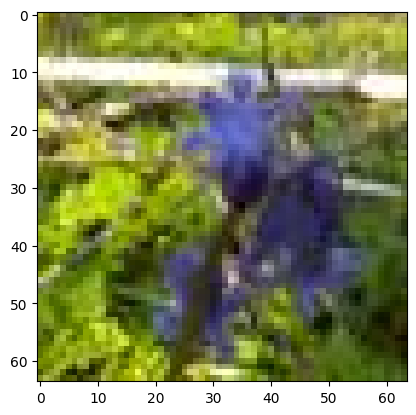

In [2]:
# Load the dataset and extract split 0
from bluebell import Bluebell

X_train_ds = Bluebell('bluebell_64', 'train', split=0)
X_val_ds = Bluebell('bluebell_64', 'val', split=0)
X_train = np.array([img.flatten()/127.5 - 1. for img, lab in X_train_ds])
y_train = np.array([lab for img, lab in X_train_ds])
X_val = np.array([img.flatten()/127.5 - 1. for img, lab in X_val_ds])
y_val = np.array([lab for img, lab in X_val_ds])
plt.imshow(X_train[0].reshape(64, 64, 3)/2+0.5)
print(y_train[0])

Next, we define the 0-1 loss that measures the error rate of a classifier.

In [3]:
def error_rate(y_hat, y):
    return (1.!=np.sign(y_hat*y)).mean()

def multi_error_rate(y_hat, y):
    return (1.*(np.argmax(y_hat, axis=1) != np.argmax(y, axis=1))).mean()

## Gradient descent

Most of this notebook uses gradient descent to optimize parameters. This first part shows how to use `pytorch`'s autograd to avoid computing gradients by hand, driven by a `torch.optim` **optimizer**. We follow a `loss.backward()` + `optimizer.step()` pattern every model class in this notebook uses.
We first define the function that we want to minimize.

In [4]:
def cost(parameters, other_value):
    return (parameters - other_value).square().sum()

`parameters` needs `requires_grad=True` so autograd records operations on it. Each step:

1. `optimizer.zero_grad()`: clear gradients from the previous step (they accumulate otherwise)
2. compute the loss
3. `loss.backward()`: fills in `parameters.grad` via autograd
4. `optimizer.step()`: the optimizer updates `parameters` using that gradient

We use `Adam` here and throughout the rest of the notebook, but you can use `SGD`.

initial cost: 114.6827163696289
final cost: 0.001241590827703476


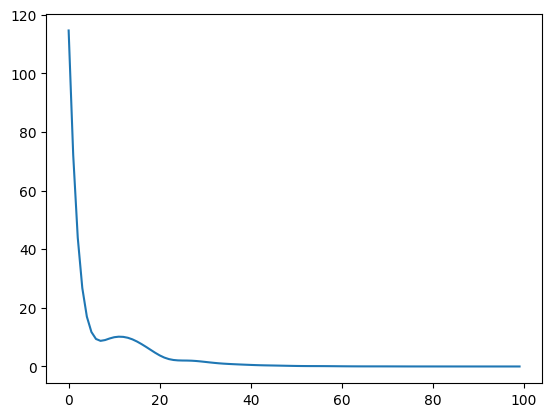

In [5]:
params = torch.randn(100, requires_grad=True)
value = torch.arange(100.)/100.
optimizer = torch.optim.Adam([params], lr=0.3)

print(f"initial cost: {cost(params, value)}")
loss = []
for i in range(100):
    optimizer.zero_grad()
    l = cost(params, value)
    loss.append(l.item())
    l.backward()
    optimizer.step()

print(f"final cost: {cost(params, value)}")

plt.plot(loss)

## Regularized linear regression

We will first try to classify Bluebell using linear regression. Since the images have 12k dimension, they are too big to use the closed-form solution directly for each hyper parameter. Instead, we will first perform PCA to reduce the dimension to something manageable.

<div class="alert alert-success"> <b> Q1.1</b> Implement a PCA class that has 2 methods: `fit` to optimize the components on a training set using gradient ascent on the variance in the projected space, and `transform` to project  a dataset with the learned projector. To respect the orthogonality constraint, orthogonalized your projectors after each gradient step (this can be done using `torch.linalg.qr` to perform the QR decomposition of the matrix and keep only the orthogonal part, or you can code by hand your own Gram-Schmidt orthogonalization method).</i>
</div>

In [6]:
class PCA():
    """
    Finds the top `n_components` principal directions via gradient-based
    *subspace power iteration*: maximize the total variance captured,
    tr(Wt . Sigma . W), subject to W having orthonormal columns.
    """

    def __init__(self, n_components, n_iter=80, lr=1.0, device=None):
        self.n_components = n_components
        self.n_iter = n_iter
        self.lr = lr
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.mu = None
        self.proj = None            # (n_components, dim), orthonormal rows

    def fit(self, X):
        # TODO:

    def transform(self, X):
        # TODO:

    def inverse_transform(self, Z):
        # TODO:

We first try a Linear on the training set reduce to digits 0 and 1 to check that our code works.

In [7]:
%%time
pca = PCA(256)
pca.fit(X_train)

CPU times: user 674 ms, sys: 527 ms, total: 1.2 s
Wall time: 1.21 s



<div class="alert alert-success"> <b> Q1.2</b> Show the first 64 principal components as images. Plot the reconstruction of one image per class using 1, 2, 4, 8, 16, 32 and 64 compoenents.</i>
</div>

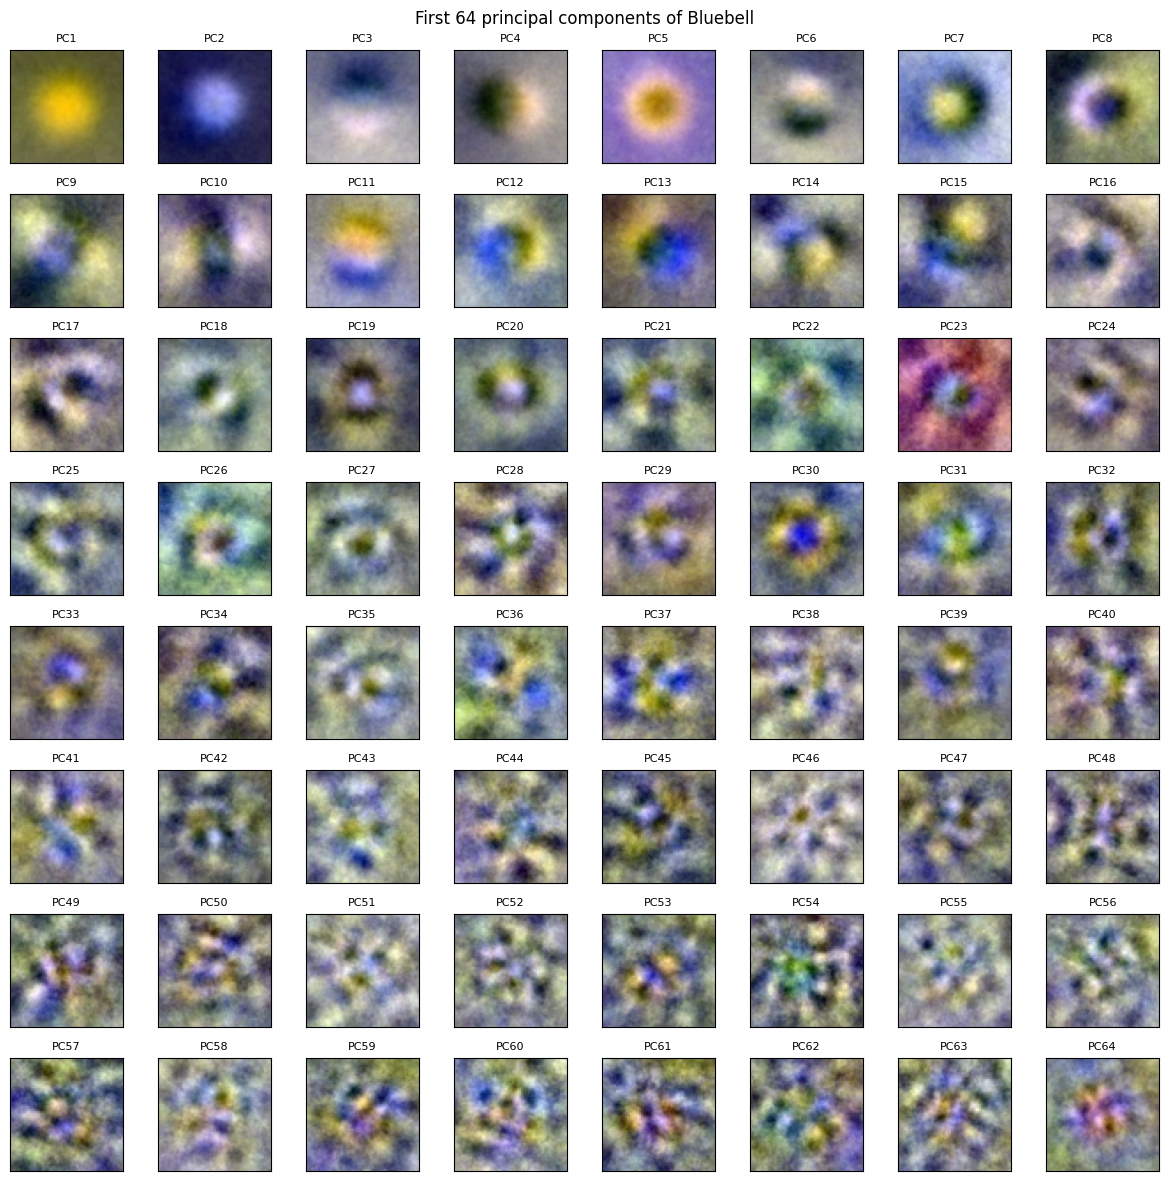

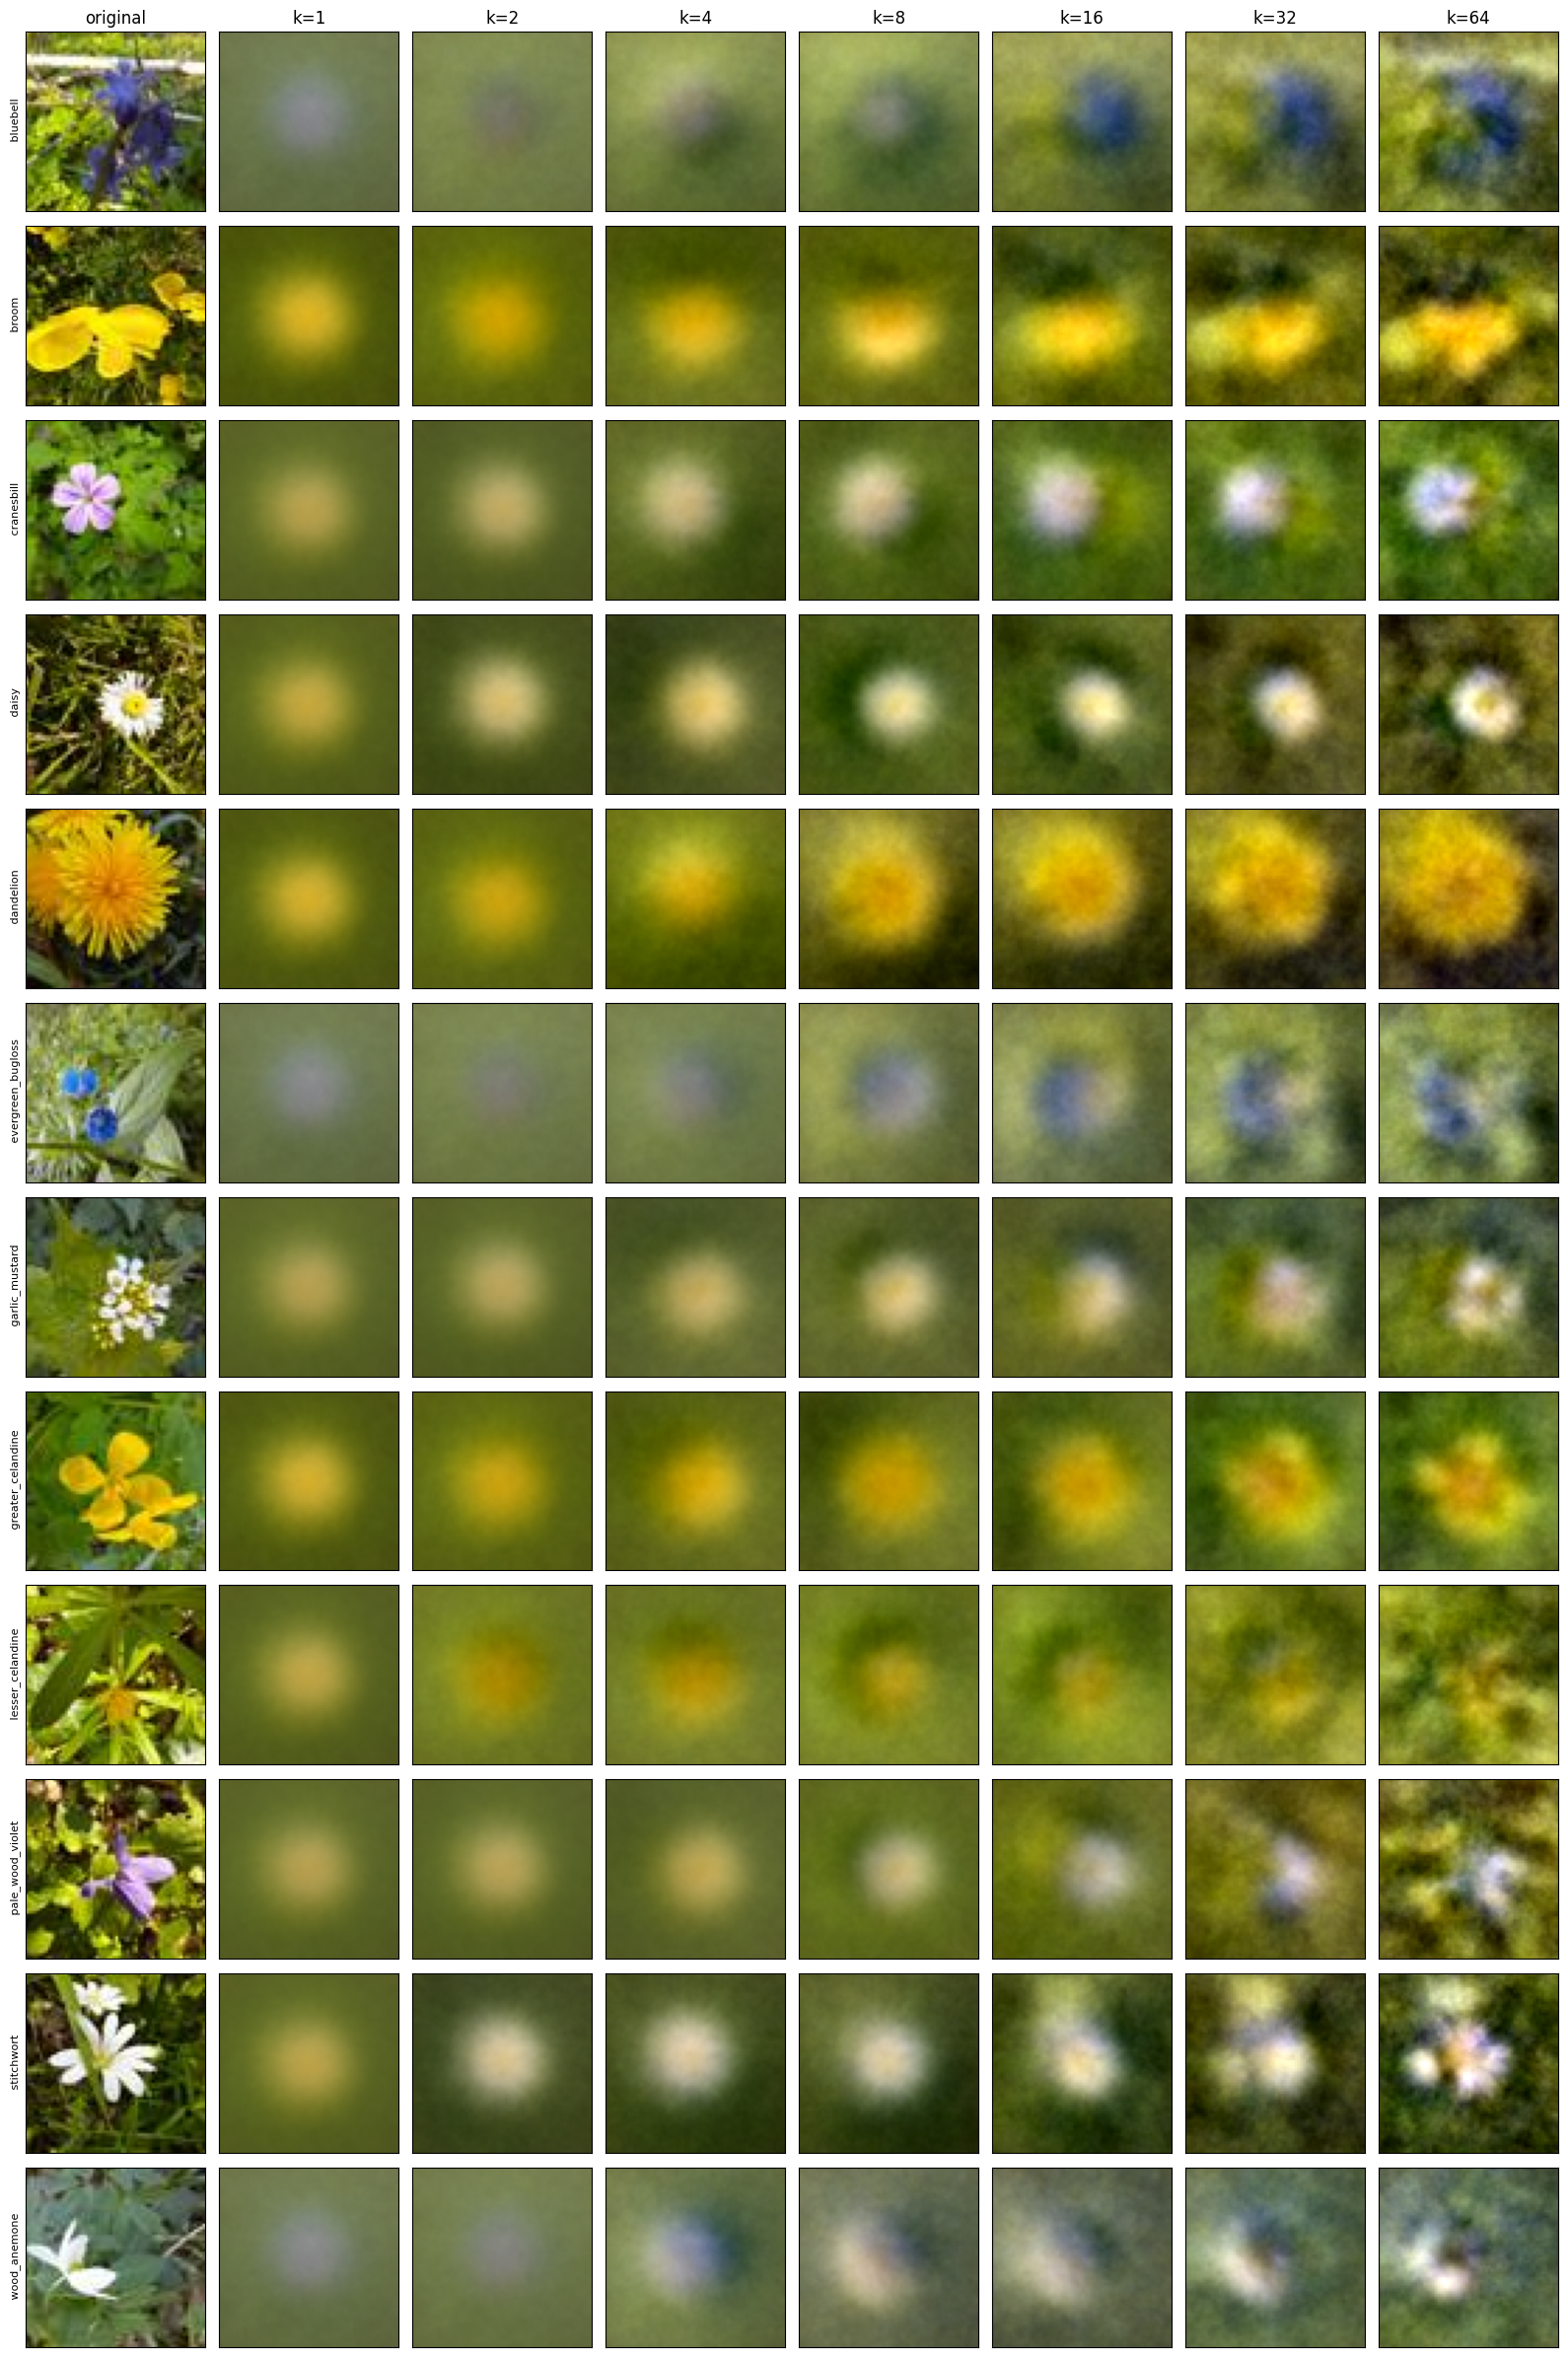

<div class="alert alert-info" role="alert"><b>Analyze your results in this box.</b>  Answer
</div>

We now only consider the bluebell dataset projected to **512 dimensions**. We first try a simple linear regression. We train one predictor per class, that tries to regress +1 if the image is of the class, -1 else.

<div class="alert alert-success"> <b> Q1.3</b> Code a class that train the 12 linear regressions using gradient descent. Train it on each of the 5 train split and evaluate it on the corresponding validation split.</i>
</div>

In [11]:
def load_split(mode, split=0):
    ds = Bluebell('bluebell_64', mode, split=split)
    X = np.array([img.flatten()/127.5 - 1. for img, lab in ds], dtype=np.float32)
    y = np.array([lab for img, lab in ds], dtype=np.int64)
    return X, y

def one_hot_pm1(y, n_classes=12):
    """+1/-1 one-vs-rest targets, shape (n, n_classes)."""
    Y = -np.ones((len(y), n_classes), dtype=np.float32)
    Y[np.arange(len(y)), y] = 1.
    return Y


class LinearRegressor():
    """
    Multi-output (one-vs-rest) linear model w^T x + b trained by gradient
    descent
    """

    def __init__(self, n_iter=300, lr=0.01, device=None):
        self.n_iter = n_iter
        self.lr = lr
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.W, self.b = None, None

    def fit(self, X, Y, n_iter=None, lr=None):
        # n_iter/lr here override the constructor's defaults if given, so
        # this class can be driven uniformly by the same cross-validation
        # harness used for RidgeRegression/LassoRegression/LinearSVM below.
        n_iter = self.n_iter if n_iter is None else n_iter
        lr = self.lr if lr is None else lr
        
        #TODO:

    def decision(self, X):
        #TODO:

    def predict_scores(self, X):
        #TODO: 

In [12]:
%%time

cached 5 splits
CPU times: user 9.31 s, sys: 5.96 s, total: 15.3 s
Wall time: 15.3 s


In [13]:
%%time


split 0: val error rate = 0.443


split 1: val error rate = 0.417


split 2: val error rate = 0.413


split 3: val error rate = 0.453


split 4: val error rate = 0.413

mean val error rate over 5 splits: 0.428 +- 0.017
CPU times: user 1.12 s, sys: 34.8 ms, total: 1.16 s
Wall time: 1.23 s


<div class="alert alert-info" role="alert"><b>Analyze your results in this box.</b>  Answer
</div>

Since we have projected the images into only 512 dimension, we ca use the close-form solution of the linear regression.
<div class="alert alert-success"> <b> Q1.4</b> Use the close form solution, and compare your results with you gradient based optimization.</i>
</div>

In [14]:
%%time

split 0: val error rate (closed form) = 0.443
split 1: val error rate (closed form) = 0.417


split 2: val error rate (closed form) = 0.413


split 3: val error rate (closed form) = 0.453
split 4: val error rate (closed form) = 0.413

mean val error rate over 5 splits: 0.428 +- 0.017
(GD gave 0.428 -- should match closely: both solve the same convex problem)
CPU times: user 1.22 s, sys: 7.59 ms, total: 1.23 s
Wall time: 331 ms


<div class="alert alert-info" role="alert"><b>Analyze your results in this box.</b>  Answer
</div>

## Regularization

Next, we want to see whether regularization helps getting a better classifier.

<div class="alert alert-success"> <b> Q2.1.</b> Code a multi-class ridge regression class that has a parameter `l_ridge` controlling the amount of l2 regularization, optimized using gradient descent. The multiclass consists in outputing the argmax among the predictors.</i>
</div>

In [15]:
class RidgeRegression():
    def __init__(self, l_ridge):
        self.l_ridge = l_ridge

    def fit(self, X, y_onehot, n_iter=500, lr=0.01):
        # TODO:

    def decision(self, X):
        # TODO:

    def predict(self, X):
        # TODO:


<div class="alert alert-success"> <b> Q2.2.</b> Perform ridge regression on both the original bluebell dataset and the one reduced to 512 dimensions using PCA. Use cross-validation to select l_ridge. compare both.</i>
</div>

l_ridge   | 512-dim PCA   | 12288-dim raw
0.0       | 0.428         | 0.512
0.0001    | 0.428         | 0.511
0.001     | 0.425         | 0.508
0.01      | 0.407         | 0.493
0.1       | 0.375         | 0.419
1.0       | 0.358         | 0.404

best l_ridge (512-dim): 1.0, val err = 0.358
best l_ridge (raw):     1.0, val err = 0.404
CPU times: user 16.8 s, sys: 256 ms, total: 17 s
Wall time: 17.9 s


Text(0.5, 1.0, 'Ridge: PCA-reduced vs. raw pixels')

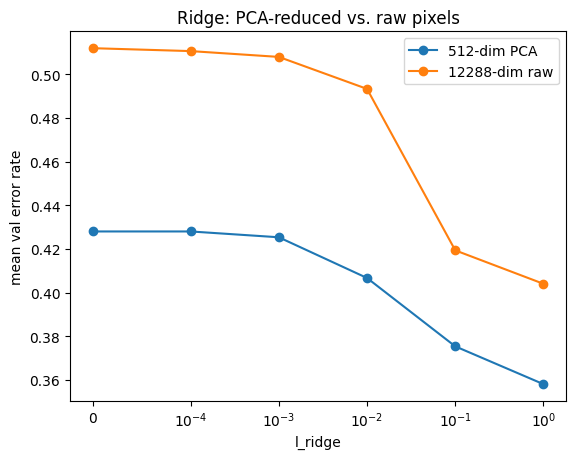

In [16]:
%%time
l_ridge_grid = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]


<div class="alert alert-info" role="alert"><b>Analyze your results on the full training set in this box.</b>  Answer
</div>

Similarly, we now want to try the LASSO.


<div class="alert alert-success"> <b> Q2.3.</b> Code a multi-class LASSO regression class that has a parameter `l_lasso` for controlling the amount of regularization, optimized using gradient descent. The multi-class consists in outputing the argmax among predictors.</i>
</div>

In [17]:
class LassoRegression():
    def __init__(self, l_lasso):
        self.l_lasso = l_lasso

    def fit(self, X, y_onehot, n_iter=500, lr=0.01):
        # TODO:

    def decision(self, X):
        # TODO:

    def predict(self, X):
        # TODO:


<div class="alert alert-success"> <b> Q2.4.</b> Perform LASSO regression on both the original bluebell dataset and the one reduced to 512 dimensions using PCA. Use cross-validation to select l_lasso. compare both.</i>
</div>

l_lasso   | 512-dim PCA   | 12288-dim raw
0.0       | 0.428         | 0.512
1e-05     | 0.428         | 0.510
0.0001    | 0.421         | 0.493
0.001     | 0.393         | 0.420
0.01      | 0.371         | 0.581
0.1       | 0.546         | 0.759

best l_lasso (512-dim): 0.01, val err = 0.371
best l_lasso (raw):     0.001, val err = 0.420
CPU times: user 16.3 s, sys: 249 ms, total: 16.6 s
Wall time: 17.7 s


Text(0.5, 1.0, 'LASSO: PCA-reduced vs. raw pixels')

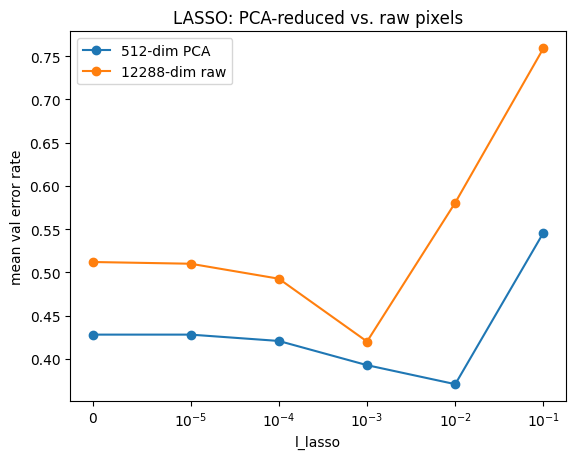

In [18]:
%%time
l_lasso_grid = [0.0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]


<div class="alert alert-info" role="alert"><b>Analyze your results on the full training set in this box.</b>  Answer
</div>

## Generalized linear models

A linear classifier is unlikely to be able to classify correctly all classes, we will thus try a generalized linear model using a non-linear projection.

<div class="alert alert-success"> <b> Q3.1.</b> Code a class that projects a dataset using polynomials of each dimension up to some specified degree.</i>
</div>

In [19]:
class PolyProjector():
    """phi(x) = [x, x^2, ..., x^degree], concatenated over the input dims."""

    def __init__(self, degree):
        self.degree = degree

    def project(self, X):
        # TODO: 

def l2_normalize(X):
    return X / np.linalg.norm(X, axis=1, keepdims=True)

We consider only the **512 dimension** of the dataset for the following questions, and we normalize each vector **to have unit l2 norm** using `l2_normalize`.

<div class="alert alert-success"> <b>Q3.2.</b> Using cross validation, find a the best degree to classify bluebell using unregularized regression.</i></div>

degree 1: mean val error = 0.444 +- 0.015
degree 2: mean val error = 0.628 +- 0.025
degree 3: mean val error = 0.642 +- 0.015
degree 4: mean val error = 0.602 +- 0.020
degree 6: mean val error = 0.621 +- 0.018
degree 8: mean val error = 0.626 +- 0.019

best degree (Occam's razor: lowest degree within 1 std of the best): 1
CPU times: user 8 s, sys: 438 ms, total: 8.44 s
Wall time: 9.05 s


Text(0.5, 1.0, 'Unregularized polynomial regression: degree vs. val error')

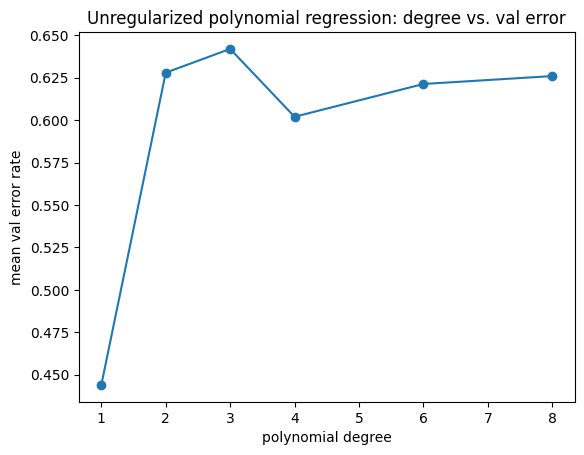

In [21]:
%%time
degree_grid = [1, 2, 3, 4, 6, 8]


<div class="alert alert-info" role="alert"><b>Analyze your results on the full training set in this box.</b>  Answer
</div>

<div class="alert alert-success"> <b>Q3.3</b> Using a maximum degree of 5 and your ridge regression class, perform cross-validation on the `l_ridge` hyper-parameter and classify bluebell.</i></div>

In [22]:
%%time

degree-5 feature dim: 2560
CPU times: user 238 ms, sys: 90.9 ms, total: 328 ms
Wall time: 328 ms


l_ridge=0.0: mean val error = 0.610
l_ridge=0.001: mean val error = 0.544
l_ridge=0.01: mean val error = 0.509
l_ridge=0.1: mean val error = 0.473
l_ridge=1.0: mean val error = 0.495
l_ridge=10.0: mean val error = 0.562

best l_ridge: 0.1, val err = 0.473
(unregularized degree-5 would be l_ridge=0: 0.610 -- regularization should help here)
CPU times: user 8.52 s, sys: 140 ms, total: 8.66 s
Wall time: 9.76 s


Text(0.5, 1.0, 'Ridge on degree-5 polynomial features')

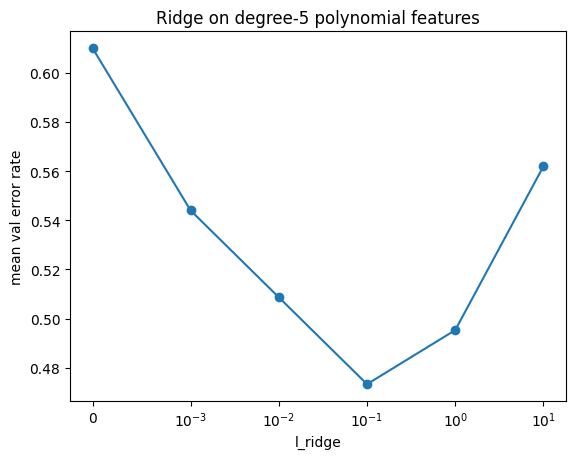

In [23]:
%%time
l_ridge_grid_poly = [0.0, 1e-3, 1e-2, 1e-1, 1.0, 10.0]

<div class="alert alert-info" role="alert"><b>Analyze your results on the full training set in this box.</b>  Answer
</div>

<div class="alert alert-success"> <b>Q3.4</b> Using a maximum degree of 5 and your LASSO regression class, perform cross-validation on the `l_ridge` hyper-parameter and classify bluebell.</i></div>

l_lasso=0.0: mean val error = 0.610
l_lasso=0.0001: mean val error = 0.506
l_lasso=0.001: mean val error = 0.400
l_lasso=0.01: mean val error = 0.477
l_lasso=0.1: mean val error = 0.886
l_lasso=1.0: mean val error = 0.930

best l_lasso: 0.001, val err = 0.400
CPU times: user 8.01 s, sys: 200 ms, total: 8.21 s
Wall time: 10.8 s


Text(0.5, 1.0, 'LASSO on degree-5 polynomial features')

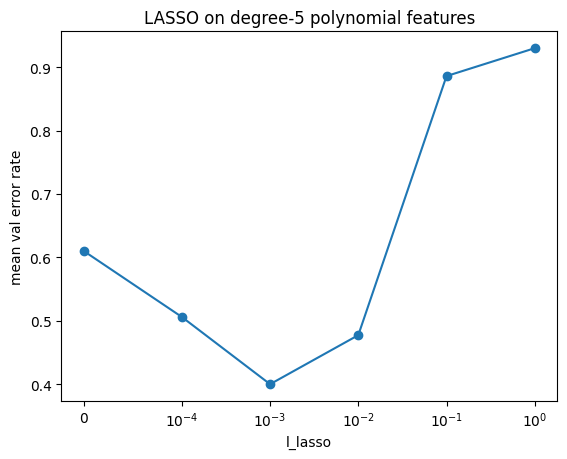

In [24]:
%%time
l_lasso_grid_poly = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

<div class="alert alert-info" role="alert"><b>Analyze your results on the full training set in this box.</b>  Answer
</div>

## Bonus

The questions in this section are bonus, they don't bring any additional point.

<div class="alert alert-warning"> <b>Q4.1 [Optional].</b> Code an `ElasticNet` class that combines ridge and LASSO. Use cross validation to select both hyper-parameters on the polynomial features of degree 5.</i></div>

In [25]:
class ElasticNet():
    def __init__(self, l_lasso, l_ridge):
        self.l_lasso = l_lasso
        self.l_ridge = l_ridge

    def fit(self, X, y_onehot, n_iter=500, lr=0.01):
        # TODO:

    def decision(self, X):
        # TODO:

    def predict(self, X):
        # TODO:

<div class="alert alert-info" role="alert"><b>Analyze your results on the full training set in this box.</b>  Answer
</div>

<div class="alert alert-warning"> <b>Q4.2 [Optional].</b> Inspired by your ridge class, code a `LinearSVM` class that replaces the MSE loss with the hinge loss. Use cross-validation on the polynomial features to set the regularization term.</i></div>

In [27]:
class LinearSVM():
    def __init__(self, l_ridge):
        self.l_ridge = l_ridge

    def fit(self, X, y_onehot, n_iter=500, lr=0.01):
        # TODO:

    def decision(self, X):
        # TODO:

    def predict(self, X):
        # TODO:

<div class="alert alert-info" role="alert"><b>Analyze your results on the full training set in this box.</b>  Answer
</div>